In [47]:
# GCS helpers: sibling folder s3-visualization-pipeline-v2/gcs_utils.py
# (Hyphenated dir names are not Python packages; we add v2 to sys.path below.)
import csv
import io
import json
import re
import sys
from pathlib import Path

import numpy as np

_v3 = Path.cwd() / "s3-visualization-pipeline-v3"
if (_v3 / "path_setup.py").is_file():
    sys.path.insert(0, str(_v3))
elif (Path.cwd() / "path_setup.py").is_file():
    sys.path.insert(0, str(Path.cwd()))

from path_setup import ensure_v2_pipeline_on_path

ensure_v2_pipeline_on_path()
from gcs_utils import GCSClient, bytes_to_image, bytes_to_mask



In [48]:
# ── Align with s2-inference-pipeline/config.yaml and s1 sampler layout ─────
# Sampler uploads under:  streetview/polygon_{n}v/{run_ts}/<filename>.jpg
# Manifest:               <that_prefix>/manifest.csv
# Per-class masks (s3-v2 / multi-prompt layout):
#   <output_prefix>/<point_id>_<lat>_<lon>/<direction>/<class_name>/mask_NNN.png
# SAM batch-only (s2 segment_gcs_batch_masks): same but one folder: .../<direction>/<prompt_slug>/
# Coordinate folders match s3-visualization-pipeline-v2/main.py (point_lat_lon for v2 names).
# Caveat: stock s2 main._parse_image_filename only accepts v1-style names (no "012-0042_" prefix);
# if batch skipped your v2 filenames, masks may be missing until inference parsing matches s1.

GCP_PROJECT_ID = "cv-urban-accessibility"
GCS_BUCKET_NAME = "cv-urban-accessibility-bucket"

# Trailing slash: list images under this run (s1 main.py gcs_prefix + "/")
SAMPLER_IMAGE_PREFIX = "streetview/polygon_4v/20260329T023321Z-BAGDAT-30m/"

# Mask layout on GCS (matches s3-visualization-pipeline-v2/main.py → img_masks):
#   {SEGMENTATION_OUTPUT_PREFIX}{coordinate_folder}/{direction}/{class_name}/mask_NNN.png
# e.g. v2/segmentation-results/0000_40.9735915_29.064327/backward/sidewalk/mask_000.png
#
# Optional: if you use SAM batch-only uploads (single prompt folder), set this and pass
# sam_prompt_subfolder=INFERENCE_PROMPT to load_one_image_bundle.
INFERENCE_PROMPT = "street furniture"

# s2 config output_prefix; s3-v2 config often uses v2/segmentation-results/
SEGMENTATION_OUTPUT_PREFIX = "v2/segmentation-results/"

PITCH_ANGLE = -10

IMAGE_BLOB_INDEX = 13

In [49]:
# Filename parsing: same rules as s3-visualization-pipeline-v2/main.py, plus left/right for v2 sampler.

_FILENAME_RE_V2 = re.compile(
    r"^(\d+)-(\d+)_(forward|backward|left|right)_([-\d.]+)_([-\d.]+)_([\d.]+)\.\w+$"
)
_FILENAME_RE_V1 = re.compile(
    r"^(\d+)_(forward|backward|left|right)_([-\d.]+)_([-\d.]+)_([\d.]+)\.\w+$"
)


def parse_streetview_blob(blob_path: str) -> dict[str, str] | None:
    """Parse sampler image path; returns coordinate_folder for mask layout (v2 pipeline)."""
    name = Path(blob_path).name
    m = _FILENAME_RE_V2.match(name)
    if m:
        return {
            "segment_id": m.group(1),
            "point_id": m.group(2),
            "direction": m.group(3),
            "lat": m.group(4),
            "lon": m.group(5),
            "heading": m.group(6),
            "coordinate_folder": f"{m.group(2)}_{m.group(4)}_{m.group(5)}",
        }
    m = _FILENAME_RE_V1.match(name)
    if m:
        return {
            "segment_id": "0",
            "point_id": m.group(1),
            "direction": m.group(2),
            "lat": m.group(3),
            "lon": m.group(4),
            "heading": m.group(5),
            "coordinate_folder": f"{m.group(1)}_{m.group(3)}_{m.group(4)}",
        }
    return None


def safe_prompt_slug(prompt: str) -> str:
    return re.sub(r"[^\w\-]+", "_", prompt).strip("_")


def masks_prefix_for_image(
    image_blob: str,
    segmentation_root: str,
    *,
    sam_prompt_subfolder: str | None = None,
) -> str:
    """
    GCS prefix for all masks of one panorama (no trailing slash).

    Default (sam_prompt_subfolder=None): per-class folders under direction, as in
    s3-visualization-pipeline-v2 and s2 sidewalk_analysis.ipynb:
      .../<coord_folder>/<direction>/sidewalk/mask_000.png

    If sam_prompt_subfolder is set (e.g. INFERENCE_PROMPT), append the slug used by
    segment_gcs_batch_masks: .../<direction>/<prompt_slug>/mask_000.png
    """
    parsed = parse_streetview_blob(image_blob)
    if parsed is None:
        raise ValueError(f"Unrecognised streetview filename: {Path(image_blob).name}")
    root = segmentation_root.rstrip("/")
    base = f"{root}/{parsed['coordinate_folder']}/{parsed['direction']}"
    if sam_prompt_subfolder:
        return f"{base}/{safe_prompt_slug(sam_prompt_subfolder)}"
    return base


gcs = GCSClient(GCP_PROJECT_ID, GCS_BUCKET_NAME)


In [50]:
def load_manifest(gcs: GCSClient, manifest_blob: str) -> dict[tuple[str, str, str], dict]:
    """
    Load sampler manifest.csv from GCS (s1-streetview-sampler-v2 uploads it next to images).

    Key: (segment_id, point_id, direction) -> row dict.
    """
    if not manifest_blob:
        return {}
    try:
        data = gcs.download_as_bytes(manifest_blob)
        reader = csv.DictReader(io.StringIO(data.decode("utf-8")))
        manifest: dict[tuple[str, str, str], dict] = {}
        for row in reader:
            key = (
                str(row.get("segment_id", "")),
                str(row.get("point_id", "")),
                str(row.get("direction", "")),
            )
            manifest[key] = row
        print(f"Loaded manifest with {len(manifest)} entries from {manifest_blob}")
        return manifest
    except Exception as e:
        print(f"Could not load manifest: {e}")
        return {}


def load_original_rgb(gcs: GCSClient, image_blob: str) -> np.ndarray:
    return bytes_to_image(gcs.download_as_bytes(image_blob))


def load_annotated_jpeg(gcs: GCSClient, masks_prefix: str) -> np.ndarray | None:
    """Try SAM-batch layout; else first .../*/annotated.jpg under masks_prefix."""
    blob = f"{masks_prefix}/annotated.jpg"
    try:
        return bytes_to_image(gcs.download_as_bytes(blob))
    except Exception:
        pass
    for name in sorted(gcs.list_blobs(masks_prefix)):
        if name.endswith("/annotated.jpg") or name.endswith("annotated.jpg"):
            try:
                return bytes_to_image(gcs.download_as_bytes(name))
            except Exception:
                continue
    return None


def load_segmentation_metadata(gcs: GCSClient, masks_prefix: str) -> dict | None:
    blob = f"{masks_prefix}/metadata.json"
    try:
        return json.loads(gcs.download_as_bytes(blob).decode("utf-8"))
    except Exception:
        pass
    for name in sorted(gcs.list_blobs(masks_prefix)):
        if name.endswith("/metadata.json"):
            try:
                return json.loads(gcs.download_as_bytes(name).decode("utf-8"))
            except Exception:
                continue
    return None


def load_mask_pngs(gcs: GCSClient, masks_prefix: str) -> dict[str, np.ndarray]:
    """
    All mask PNGs under masks_prefix (recursive listing).

    Per-class layout (s3-v2): .../<direction>/<class>/mask_NNN.png → keys ``class/mask_NNN``.

    Flat SAM-batch layout: .../<prompt>/mask_NNN.png → keys ``mask_NNN``.
    """
    blobs = sorted(gcs.list_blobs(masks_prefix))
    masks: dict[str, np.ndarray] = {}
    for name in blobs:
        if not name.endswith(".png"):
            continue
        base = Path(name).name
        if not base.startswith("mask_"):
            continue
        parts = name.split("/")
        stem = base[:-4]  # .png
        if len(parts) >= 2 and parts[-2] and parts[-2] != Path(masks_prefix).name:
            class_name = parts[-2]
            key = f"{class_name}/{stem}"
        else:
            key = stem
        masks[key] = bytes_to_mask(gcs.download_as_bytes(name))
    return dict(sorted(masks.items()))


def load_one_image_bundle(
    gcs: GCSClient,
    image_blob: str,
    *,
    segmentation_root: str = SEGMENTATION_OUTPUT_PREFIX,
    sam_prompt_subfolder: str | None = None,
    manifest: dict[tuple[str, str, str], dict] | None = None,
) -> dict:
    """Original + optional manifest row + masks under .../<coord>/<direction>/ (per-class or SAM subfolder)."""
    parsed = parse_streetview_blob(image_blob)
    if parsed is None:
        raise ValueError(f"Bad image blob: {image_blob}")
    masks_prefix = masks_prefix_for_image(
        image_blob, segmentation_root, sam_prompt_subfolder=sam_prompt_subfolder
    )
    row = None
    if manifest is not None:
        key = (parsed["segment_id"], parsed["point_id"], parsed["direction"])
        row = manifest.get(key)
    return {
        "image_blob": image_blob,
        "masks_prefix": masks_prefix,
        "segmentation_prefix": masks_prefix,
        "parsed": parsed,
        "manifest_row": row,
        "original": load_original_rgb(gcs, image_blob),
        "annotated": load_annotated_jpeg(gcs, masks_prefix),
        "metadata": load_segmentation_metadata(gcs, masks_prefix),
        "masks": load_mask_pngs(gcs, masks_prefix),
    }


In [51]:
# Manifest path: <sampler_prefix>manifest.csv  (see s1-streetview-sampler-v2/main.py)
MANIFEST_BLOB = SAMPLER_IMAGE_PREFIX.rstrip("/") + "/manifest.csv"
manifest = load_manifest(gcs, MANIFEST_BLOB)

# Pick one image blob (full path in bucket). Example matches s2 config.yaml single-image style:
# IMAGE_BLOB = "streetview/polygon_4v/20260221T142707Z/0598_forward_40.9715456_29.0555065_123.0.jpg"

blobs = sorted(gcs.list_blobs(SAMPLER_IMAGE_PREFIX))
image_blobs = [b for b in blobs if b.lower().endswith((".jpg", ".jpeg", ".png"))]
IMAGE_BLOB = image_blobs[IMAGE_BLOB_INDEX] if image_blobs else ""
print("First image under prefix:", IMAGE_BLOB)

if IMAGE_BLOB:
    bundle = load_one_image_bundle(gcs, IMAGE_BLOB, manifest=manifest)
    print("Segmentation prefix:", bundle["segmentation_prefix"])
    print("Original shape:", bundle["original"].shape)
    print("Mask indices:", list(bundle["masks"].keys()))
    if bundle["metadata"]:
        print("detection_count:", bundle["metadata"].get("detection_count"))


Loaded manifest with 286 entries from streetview/polygon_4v/20260329T023321Z-BAGDAT-30m/manifest.csv
First image under prefix: streetview/polygon_4v/20260329T023321Z-BAGDAT-30m/001-0006_forward_40.9715613_29.066227_305.6.jpg
Segmentation prefix: v2/segmentation-results/0006_40.9715613_29.066227/forward
Original shape: (640, 640, 3)
Mask indices: ['bollard/mask_000', 'bollard/mask_001', 'car/mask_000', 'car/mask_001', 'car/mask_002', 'car/mask_003', 'car/mask_004', 'car/mask_005', 'road/mask_000', 'sidewalk/mask_000', 'sidewalk/mask_001', 'tree/mask_000', 'tree/mask_001', 'tree/mask_002']
detection_count: 2


/var/folders/_l/h44zx0_s3pd47gnlplq87_1h0000gn/T/ipykernel_85775/558844622.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(n, 1))


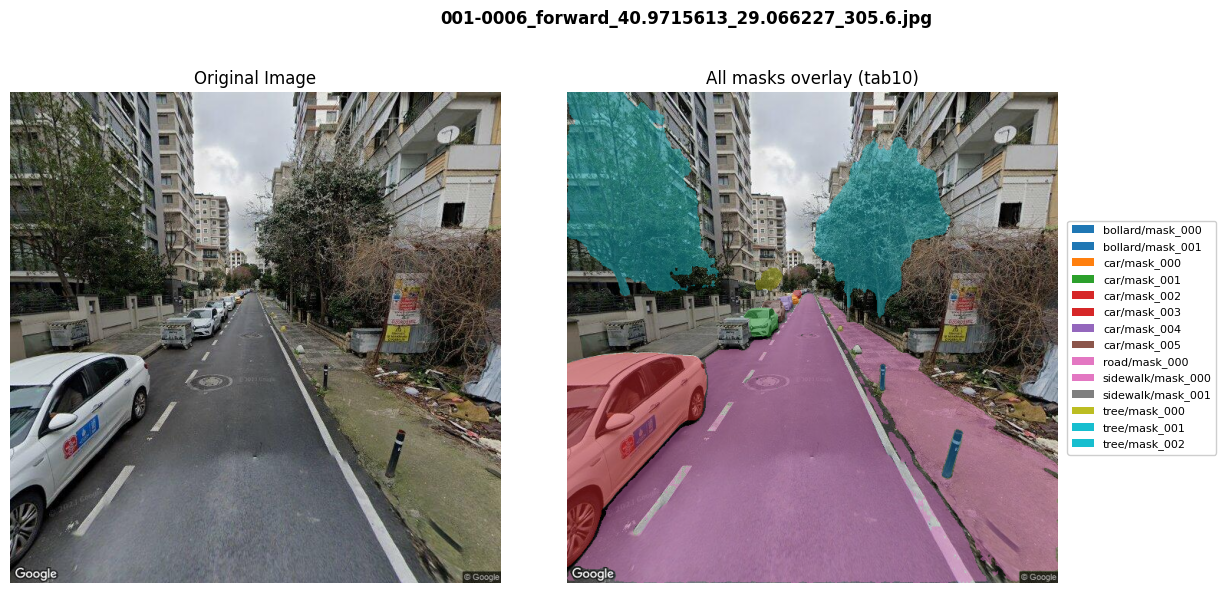

In [52]:
# Original vs every mask, each in its own tab10 color (s3-v2 style)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def compose_all_masks_overlay(
    original: np.ndarray,
    masks: dict[str, np.ndarray],
    *,
    alpha: float = 0.45,
) -> tuple[np.ndarray, list[tuple[str, tuple]]]:
    """RGB float [0,1]: base image with each mask tinted (tab10), later keys paint on top."""
    base = np.clip(original.astype(np.float64) / 255.0, 0.0, 1.0)
    h, w = base.shape[:2]
    out = base.copy()
    n = max(len(masks), 1)
    cmap = plt.cm.get_cmap("tab10", max(n, 1))
    legend_entries: list[tuple[str, tuple]] = []
    for i, k in enumerate(sorted(masks.keys())):
        m = np.asarray(masks[k], dtype=bool)
        if m.shape[:2] != (h, w):
            raise ValueError(f"mask {k} shape {m.shape} != image {(h, w)}")
        rgb = np.asarray(cmap(i)[:3], dtype=np.float64)
        legend_entries.append((k, tuple(float(x) for x in rgb)))
        for c in range(3):
            out[..., c] = np.where(
                m,
                (1.0 - alpha) * out[..., c] + alpha * rgb[c],
                out[..., c],
            )
    return np.clip(out, 0.0, 1.0), legend_entries


if "bundle" not in dir():
    print("Run the cell that builds `bundle` first.")
elif not bundle.get("masks"):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(bundle["original"])
    ax.set_title("Original (no mask_*.png under segmentation prefix)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    overlay, legend_entries = compose_all_masks_overlay(
        bundle["original"], bundle["masks"], alpha=0.45
    )
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].imshow(bundle["original"])
    axes[0].set_title("Original Image")
    axes[1].imshow(overlay)
    axes[1].set_title("All masks overlay (tab10)")

    handles = [Patch(facecolor=rgb, label=k) for k, rgb in legend_entries]
    axes[1].legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
        fontsize=8,
        framealpha=0.95,
    )

    for ax in axes:
        ax.axis("off")
    plt.suptitle(Path(bundle["image_blob"]).name, fontsize=12, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 0.88, 0.96])
    plt.show()


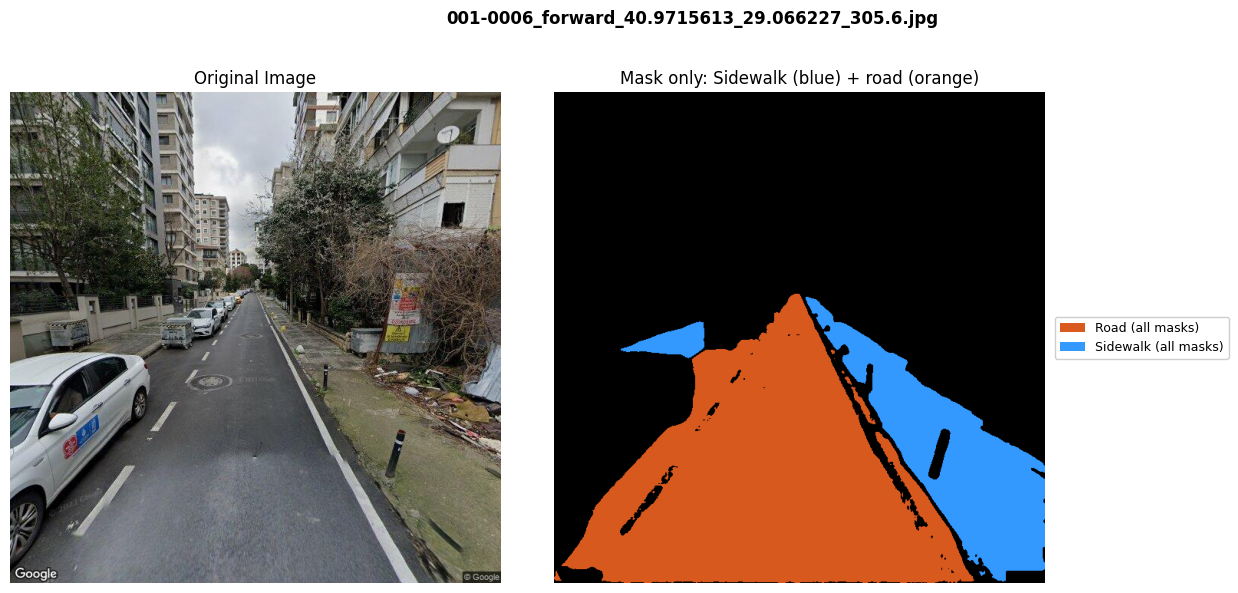

In [53]:
# Sidewalk (one blue) + road (one orange): unions of all masks in those class folders
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def _class_token_from_mask_key(key: str) -> str:
    return key.split("/", 1)[0].lower() if "/" in key else ""

def compose_sidewalk_and_road_mask(
    original: np.ndarray,
    masks: dict[str, np.ndarray],
    *,
    sidewalk_rgb: tuple[float, float, float] = (0.2, 0.6, 1.0),
    road_rgb: tuple[float, float, float] = (0.85, 0.35, 0.12),
) -> tuple[np.ndarray, list[tuple[str, tuple[float, float, float]]]]:
    """
    Create a mask image (on a black background) indicating sidewalk and road unions.
    Removes the background/original image, so only color-masked areas visible.
    Road is drawn under, sidewalk on top.
    """
    h, w = original.shape[:2]
    sw = np.zeros((h, w), dtype=bool)
    rd = np.zeros((h, w), dtype=bool)
    for key, m in masks.items():
        tok = _class_token_from_mask_key(key)
        m = np.asarray(m, dtype=bool)
        if m.shape[:2] != (h, w):
            raise ValueError(f"mask {key!r} shape {m.shape} != image {(h, w)}")
        if "sidewalk" in tok:
            sw |= m
        if "road" in tok:
            rd |= m
    out = np.zeros((h, w, 3), dtype=np.float32)
    for c in range(3):
        out[..., c] = np.where(
            rd, road_rgb[c], out[..., c]
        )
    for c in range(3):
        out[..., c] = np.where(
            sw, sidewalk_rgb[c], out[..., c]
        )
    legend: list[tuple[str, tuple[float, float, float]]] = []
    if rd.any():
        legend.append(("Road (all masks)", road_rgb))
    if sw.any():
        legend.append(("Sidewalk (all masks)", sidewalk_rgb))
    return np.clip(out, 0.0, 1.0), legend

if "bundle" not in dir():
    print("Run the cell that builds `bundle` first.")
elif not bundle.get("masks"):
    print("No masks in bundle.")
else:
    overlay, legend_entries = compose_sidewalk_and_road_mask(
        bundle["original"], bundle["masks"]
    )
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].imshow(bundle["original"])
    axes[0].set_title("Original Image")
    axes[1].imshow(overlay)
    axes[1].set_title("Mask only: Sidewalk (blue) + road (orange)")

    if legend_entries:
        handles = [Patch(facecolor=rgb, label=label) for label, rgb in legend_entries]
        axes[1].legend(
            handles=handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0,
            fontsize=9,
            framealpha=0.95,
        )
    else:
        axes[1].set_title("No sidewalk/road masks (check class folder names)")

    for ax in axes:
        ax.axis("off")
    plt.suptitle(Path(bundle["image_blob"]).name, fontsize=12, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 0.88, 0.96])
    plt.show()


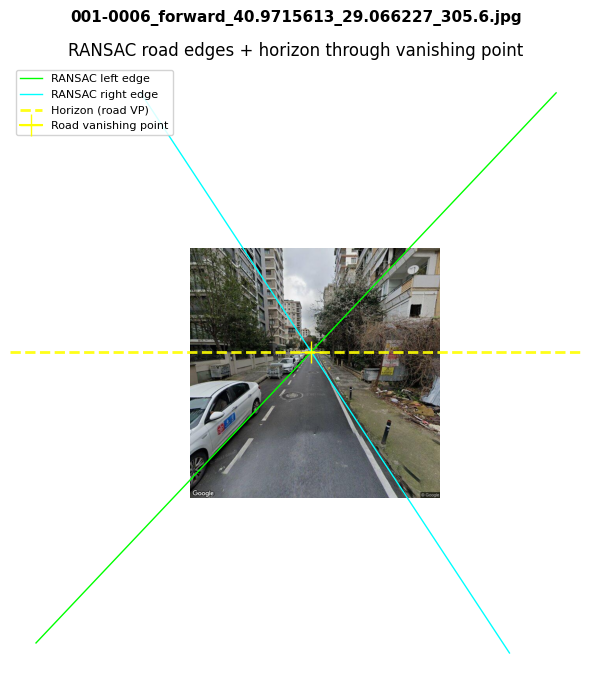

In [54]:
# RANSAC: two lines along the road mask left/right edges; they meet at a vanishing point on the horizon.
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import LineModelND, ransac


def road_union_mask(masks: dict[str, np.ndarray], h: int, w: int) -> np.ndarray:
    rd = np.zeros((h, w), dtype=bool)
    for key, m in masks.items():
        tok = _class_token_from_mask_key(key)
        m = np.asarray(m, dtype=bool)
        if m.shape[:2] != (h, w):
            continue
        if "road" in tok:
            rd |= m
    return rd


def left_right_boundary_points(
    rd: np.ndarray,
    *,
    min_row_width: int = 12,
    y_min_frac: float = 0.35,
    y_max_frac: float = 1.0,
    border_margin_px: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Per-row leftmost / rightmost road pixels (image x, y), restricted to a vertical band.

    Rows where the mask meets the left or right image edge are skipped for that side only,
    so clipped roads (e.g. mask flush with the right border) do not contribute a fake edge.
    """
    h, w = rd.shape
    margin = border_margin_px if border_margin_px is not None else max(4, int(0.008 * w))
    margin = min(margin, w // 4)
    x_left_ok = margin
    x_right_ok = w - 1 - margin
    y0 = int(h * y_min_frac)
    y1 = int(h * y_max_frac)
    left_list: list[tuple[float, float]] = []
    right_list: list[tuple[float, float]] = []
    for y in range(y0, y1):
        cols = np.flatnonzero(rd[y])
        if cols.size < min_row_width:
            continue
        xmin = int(cols.min())
        xmax = int(cols.max())
        if xmin >= x_left_ok:
            left_list.append((float(xmin), float(y)))
        if xmax <= x_right_ok:
            right_list.append((float(xmax), float(y)))
    left = np.asarray(left_list, dtype=np.float64)
    right = np.asarray(right_list, dtype=np.float64)
    return left, right


def intersect_lines_2d(o1: np.ndarray, d1: np.ndarray, o2: np.ndarray, d2: np.ndarray) -> np.ndarray | None:
    """Return intersection of lines o + t*d in (x, y), or None if nearly parallel."""
    A = np.column_stack([d1, -d2])
    b = o2 - o1
    det = np.linalg.det(A)
    if abs(det) < 1e-10:
        return None
    t, _s = np.linalg.solve(A, b)
    return o1 + t * d1


def clip_line_to_rect(
    o: np.ndarray,
    d: np.ndarray,
    w: int,
    h: int,
    *,
    pad: float = 400.0,
) -> tuple[np.ndarray, np.ndarray] | None:
    """Two endpoints on an infinite line visible inside [-pad,w+pad] x [-pad,h+pad]."""
    ts = np.linspace(-8000.0, 8000.0, 1600)
    pts = o + np.outer(ts, d)
    m = (
        (pts[:, 0] >= -pad)
        & (pts[:, 0] <= w - 1 + pad)
        & (pts[:, 1] >= -pad)
        & (pts[:, 1] <= h - 1 + pad)
    )
    if not np.any(m):
        return None
    idx = np.flatnonzero(m)
    return pts[idx[0]], pts[idx[-1]]


def sidewalk_vp_matches_road_horizon(
    vp_sw: np.ndarray,
    vp_road: np.ndarray | None,
    h: int,
    w: int,
    *,
    max_dy_frac_vs_road: float = 0.22,
    max_dx_frac_vs_road: float = 0.45,
) -> tuple[bool, str]:
    """
    Road RANSAC defines the horizon; curvy / turning sidewalks can mis-fit outer lines.
    Accept the sidewalk outer-line intersection only if it agrees with that horizon:
    same row y as road VP (within tolerance), and x not wildly far from road VP.
    """
    if vp_road is None:
        return False, "no road vanishing point"
    dy = abs(float(vp_sw[1]) - float(vp_road[1]))
    lim_y = max_dy_frac_vs_road * h
    if dy > lim_y:
        return False, f"sidewalk outer VP Δy vs road horizon={dy:.0f}px (limit {lim_y:.0f}px)"
    dx = abs(float(vp_sw[0]) - float(vp_road[0]))
    lim_x = max_dx_frac_vs_road * w
    if dx > lim_x:
        return False, f"sidewalk outer VP Δx vs road VP={dx:.0f}px (limit {lim_x:.0f}px)"
    return True, ""


if "bundle" not in dir() or not bundle.get("masks"):
    print("Run the cells that build `bundle` with masks first.")
else:
    orig = bundle["original"]
    h, w = orig.shape[:2]
    rd = road_union_mask(bundle["masks"], h, w)
    left_xy, right_xy = left_right_boundary_points(rd)

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(orig)
    ax.set_title("RANSAC road edges + horizon through vanishing point")

    if left_xy.shape[0] < 15 or right_xy.shape[0] < 15:
        ax.set_title("Not enough road boundary samples (need wider road mask rows)")
    else:
        res_thr = max(3.0, 0.002 * float(w))
        left_model, _ = ransac(
            left_xy,
            LineModelND,
            min_samples=2,
            residual_threshold=res_thr,
            max_trials=2500,
        )
        right_model, _ = ransac(
            right_xy,
            LineModelND,
            min_samples=2,
            residual_threshold=res_thr,
            max_trials=2500,
        )
        if not left_model or not right_model:
            ax.set_title("RANSAC failed to fit one of the road edges")
        else:
            o1, d1 = np.asarray(left_model.origin), np.asarray(left_model.direction)
            o2, d2 = np.asarray(right_model.origin), np.asarray(right_model.direction)
            vp = intersect_lines_2d(o1, d1, o2, d2)
            if vp is None:
                ax.set_title("RANSAC lines nearly parallel — cannot find vanishing point")
            else:
                seg_l = clip_line_to_rect(o1, d1, w, h)
                seg_r = clip_line_to_rect(o2, d2, w, h)
                if seg_l and seg_r:
                    (p0l, p1l), (p0r, p1r) = seg_l, seg_r
                    ax.plot(
                        [p0l[0], p1l[0]],
                        [p0l[1], p1l[1]],
                        color="lime",
                        linewidth=1,
                        label="RANSAC left edge",
                    )
                    ax.plot(
                        [p0r[0], p1r[0]],
                        [p0r[1], p1r[1]],
                        color="cyan",
                        linewidth=1,
                        label="RANSAC right edge",
                    )
                ax.axhline(y=float(vp[1]), color="yellow", linestyle="--", linewidth=2.0, alpha=0.9, label="Horizon (road VP)")
                ax.plot(float(vp[0]), float(vp[1]), marker="+", markersize=16, color="yellow", label="Road vanishing point")
                ax.legend(loc="upper left", fontsize=8, framealpha=0.85)

    ax.axis("off")
    plt.suptitle(Path(bundle["image_blob"]).name, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


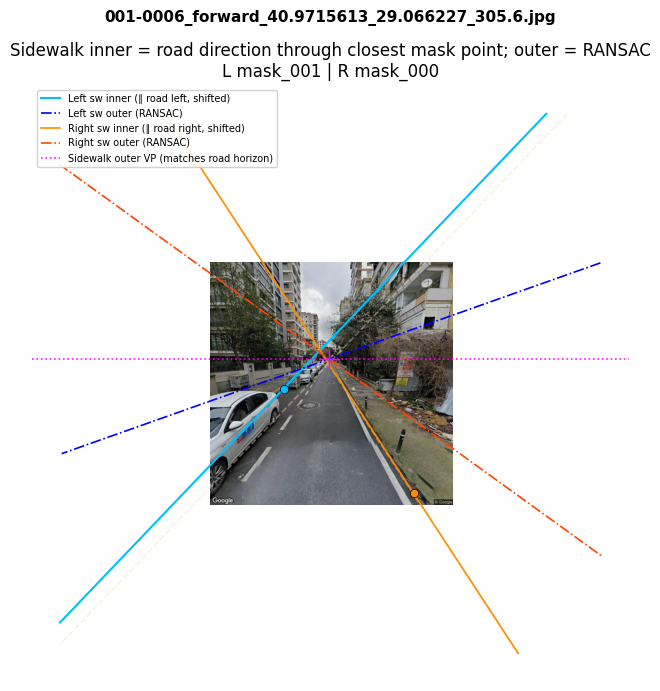

In [55]:
# Sidewalk lines: inner edges parallel to road RANSAC (shifted to closest mask point);
# outer edges from RANSAC on curb sides. Road VP defines horizon; outer sidewalk VP is shown
# only if it agrees (curvy/occluded sidewalks often fail this check).
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import LineModelND, ransac

# Needs cell 6 (`_class_token_from_mask_key`) and cell 7:
# `road_union_mask`, `left_right_boundary_points`, `intersect_lines_2d`, `clip_line_to_rect`.


def sidewalk_union_by_keys(masks: dict[str, np.ndarray], keys: list[str], h: int, w: int) -> np.ndarray:
    u = np.zeros((h, w), dtype=bool)
    for k in keys:
        m = np.asarray(masks[k], dtype=bool)
        if m.shape[:2] == (h, w):
            u |= m
    return u


def list_sidewalk_keys(masks: dict[str, np.ndarray]) -> list[str]:
    return [k for k in masks if "sidewalk" in _class_token_from_mask_key(k)]


def split_sidewalk_keys_lr(
    masks: dict[str, np.ndarray],
    road: np.ndarray,
) -> tuple[list[str], list[str]]:
    """Split sidewalk mask keys into left-side vs right-side groups (relative to road or image span)."""
    keys = list_sidewalk_keys(masks)
    if not keys:
        return [], []
    items: list[tuple[str, float]] = []
    for k in keys:
        m = np.asarray(masks[k], dtype=bool)
        xs = np.where(m)[1]
        if xs.size == 0:
            continue
        items.append((k, float(xs.mean())))
    if not items:
        return [], []
    items.sort(key=lambda t: t[1])
    if len(items) == 1:
        return [items[0][0]], []

    def partition_by_xcut(cut: float, *, le_left: bool) -> tuple[list[str], list[str]]:
        left, right = [], []
        for k, x in items:
            if le_left:
                (left if x < cut else right).append(k)
            else:
                (left if x <= cut else right).append(k)
        return left, right

    left_k: list[str] = []
    right_k: list[str] = []
    if road.any():
        rcx = float(np.where(road)[1].mean())
        left_k, right_k = partition_by_xcut(rcx, le_left=True)
    if not left_k or not right_k:
        mid = 0.5 * (items[0][1] + items[-1][1])
        left_k, right_k = partition_by_xcut(mid, le_left=False)
    if not left_k or not right_k:
        n = len(items) // 2
        left_k = [t[0] for t in items[:n]]
        right_k = [t[0] for t in items[n:]]
    return left_k, right_k


def boundary_points_outer_edge(
    m: np.ndarray,
    side: str,
    *,
    min_row_width: int = 8,
    y_min_frac: float = 0.35,
    y_max_frac: float = 1.0,
    border_margin_px: int | None = None,
) -> np.ndarray:
    """`left`: min-x per row (outer edge of left sidewalk). `right`: max-x (outer of right sidewalk)."""
    h, w = m.shape
    margin = border_margin_px if border_margin_px is not None else max(4, int(0.008 * w))
    margin = min(margin, w // 4)
    x_left_ok = margin
    x_right_ok = w - 1 - margin
    y0 = int(h * y_min_frac)
    y1 = int(h * y_max_frac)
    pts: list[tuple[float, float]] = []
    for y in range(y0, y1):
        cols = np.flatnonzero(m[y])
        if cols.size < min_row_width:
            continue
        if side == "left":
            xmin = int(cols.min())
            if xmin >= x_left_ok:
                pts.append((float(xmin), float(y)))
        else:
            xmax = int(cols.max())
            if xmax <= x_right_ok:
                pts.append((float(xmax), float(y)))
    return np.asarray(pts, dtype=np.float64)


def closest_mask_point_to_line(m: np.ndarray, o: np.ndarray, d: np.ndarray) -> np.ndarray | None:
    """Mask pixel (x, y) with smallest orthogonal distance to line through o with direction d."""
    ys, xs = np.where(m)
    if ys.size == 0:
        return None
    d = np.asarray(d, dtype=np.float64).reshape(2)
    d = d / (np.linalg.norm(d) + 1e-12)
    o = np.asarray(o, dtype=np.float64).reshape(2)
    pts = np.column_stack([xs.astype(np.float64), ys.astype(np.float64)])
    v = pts - o
    proj_len = v @ d
    closest_on_line = o + (proj_len[:, None] * d)
    dists = np.linalg.norm(pts - closest_on_line, axis=1)
    return pts[int(np.argmin(dists))].copy()


def fit_road_ransac_edges(
    rd: np.ndarray,
    w: int,
) -> tuple[np.ndarray | None, np.ndarray | None, np.ndarray | None, np.ndarray | None, str | None]:
    left_xy, right_xy = left_right_boundary_points(rd)
    if left_xy.shape[0] < 15 or right_xy.shape[0] < 15:
        return None, None, None, None, "not_enough_road_boundary"
    res_thr = max(3.0, 0.002 * float(w))
    lm, _ = ransac(left_xy, LineModelND, min_samples=2, residual_threshold=res_thr, max_trials=2500)
    rm, _ = ransac(right_xy, LineModelND, min_samples=2, residual_threshold=res_thr, max_trials=2500)
    if not lm or not rm:
        return None, None, None, None, "road_ransac_failed"
    o1 = np.asarray(lm.origin, dtype=np.float64).reshape(2)
    d1 = np.asarray(lm.direction, dtype=np.float64).reshape(2)
    o2 = np.asarray(rm.origin, dtype=np.float64).reshape(2)
    d2 = np.asarray(rm.direction, dtype=np.float64).reshape(2)
    d1 = d1 / (np.linalg.norm(d1) + 1e-12)
    d2 = d2 / (np.linalg.norm(d2) + 1e-12)
    return o1, d1, o2, d2, None


if "bundle" not in dir() or not bundle.get("masks"):
    print("Run the cells that build `bundle` with masks first (and cell 7 for road helpers).")
elif "left_right_boundary_points" not in dir() or "sidewalk_vp_matches_road_horizon" not in dir():
    print("Run cell 7 first (road helpers + sidewalk_vp_matches_road_horizon).")
else:
    orig = bundle["original"]
    h, w = orig.shape[:2]
    masks = bundle["masks"]
    rd = road_union_mask(masks, h, w)

    o_rl, d_rl, o_rr, d_rr, err = fit_road_ransac_edges(rd, w)
    if err:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.imshow(orig)
        ax.set_title(f"Sidewalk fit skipped: road — {err}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        sk_left_keys, sk_right_keys = split_sidewalk_keys_lr(masks, rd)
        sw_l = sidewalk_union_by_keys(masks, sk_left_keys, h, w)
        sw_r = sidewalk_union_by_keys(masks, sk_right_keys, h, w)

        fig, ax = plt.subplots(1, 1, figsize=(13, 7))
        ax.imshow(orig)

        for o, d in ((o_rl, d_rl), (o_rr, d_rr)):
            seg = clip_line_to_rect(o, d, w, h)
            if seg:
                p0, p1 = seg
                ax.plot(
                    [p0[0], p1[0]],
                    [p0[1], p1[1]],
                    color="wheat",
                    linewidth=1.2,
                    alpha=0.4,
                    linestyle="--",
                )

        vp_road = intersect_lines_2d(o_rl, d_rl, o_rr, d_rr)
        outer_lo = outer_ld = outer_ro = outer_rd = None

        if sw_l.any():
            p_touch = closest_mask_point_to_line(sw_l, o_rl, d_rl)
            if p_touch is not None:
                seg = clip_line_to_rect(p_touch, d_rl, w, h)
                if seg:
                    p0, p1 = seg
                    ax.plot(
                        [p0[0], p1[0]],
                        [p0[1], p1[1]],
                        color="deepskyblue",
                        linewidth=1.5,
                        label="Left sw inner (∥ road left, shifted)",
                    )
                ax.scatter([p_touch[0]], [p_touch[1]], s=36, c="deepskyblue", edgecolors="k", linewidths=0.5, zorder=5)
            ol = boundary_points_outer_edge(sw_l, "left")
            if ol.shape[0] >= 12:
                m_ol, _ = ransac(
                    ol,
                    LineModelND,
                    min_samples=2,
                    residual_threshold=max(3.0, 0.002 * float(w)),
                    max_trials=2500,
                )
                if m_ol:
                    outer_lo = np.asarray(m_ol.origin, dtype=np.float64).reshape(2)
                    outer_ld = np.asarray(m_ol.direction, dtype=np.float64).reshape(2)
                    outer_ld = outer_ld / (np.linalg.norm(outer_ld) + 1e-12)
                    seg = clip_line_to_rect(outer_lo, outer_ld, w, h)
                    if seg:
                        p0, p1 = seg
                        ax.plot(
                            [p0[0], p1[0]],
                            [p0[1], p1[1]],
                            color="blue",
                            linewidth=1.2,
                            linestyle="-.",
                            label="Left sw outer (RANSAC)",
                        )

        if sw_r.any():
            p_touch = closest_mask_point_to_line(sw_r, o_rr, d_rr)
            if p_touch is not None:
                seg = clip_line_to_rect(p_touch, d_rr, w, h)
                if seg:
                    p0, p1 = seg
                    ax.plot(
                        [p0[0], p1[0]],
                        [p0[1], p1[1]],
                        color="darkorange",
                        linewidth=1.2,
                        label="Right sw inner (∥ road right, shifted)",
                    )
                ax.scatter([p_touch[0]], [p_touch[1]], s=36, c="darkorange", edgecolors="k", linewidths=0.5, zorder=5)
            or_pts = boundary_points_outer_edge(sw_r, "right")
            if or_pts.shape[0] >= 12:
                m_or, _ = ransac(
                    or_pts,
                    LineModelND,
                    min_samples=2,
                    residual_threshold=max(3.0, 0.002 * float(w)),
                    max_trials=2500,
                )
                if m_or:
                    outer_ro = np.asarray(m_or.origin, dtype=np.float64).reshape(2)
                    outer_rd = np.asarray(m_or.direction, dtype=np.float64).reshape(2)
                    outer_rd = outer_rd / (np.linalg.norm(outer_rd) + 1e-12)
                    seg = clip_line_to_rect(outer_ro, outer_rd, w, h)
                    if seg:
                        p0, p1 = seg
                        ax.plot(
                            [p0[0], p1[0]],
                            [p0[1], p1[1]],
                            color="orangered",
                            linewidth=1.2,
                            linestyle="-.",
                            label="Right sw outer (RANSAC)",
                        )

        subtitle = []
        if sk_left_keys:
            subtitle.append("L " + ", ".join(k.split("/")[-1][:24] for k in sk_left_keys))
        if sk_right_keys:
            subtitle.append("R " + ", ".join(k.split("/")[-1][:24] for k in sk_right_keys))
        vp_note_lines: list[str] = []
        if outer_lo is not None and outer_ro is not None:
            vp_sw = intersect_lines_2d(outer_lo, outer_ld, outer_ro, outer_rd)
            if vp_sw is None:
                vp_note_lines.append("outer sidewalk lines parallel — no VP")
            else:
                ok_sw, vp_sw_msg = sidewalk_vp_matches_road_horizon(vp_sw, vp_road, h, w)
                if ok_sw:
                    ax.axhline(
                        y=float(vp_sw[1]),
                        color="magenta",
                        linestyle=":",
                        linewidth=1.2,
                        alpha=0.9,
                        label="Sidewalk outer VP (matches road horizon)",
                    )
                    ax.plot(float(vp_sw[0]), float(vp_sw[1]), marker="+", markersize=14, color="magenta")
                else:
                    vp_note_lines.append("outer sidewalk VP rejected vs road horizon: " + vp_sw_msg)
        ax.set_title(
            "Sidewalk inner = road direction through closest mask point; outer = RANSAC\n"
            + (" | ".join(subtitle) if subtitle else "(no sidewalk keys)")
            + (("\n" + "; ".join(vp_note_lines)) if vp_note_lines else "")
        )

        ax.legend(loc="upper left", fontsize=7, framealpha=0.9)
        ax.axis("off")
        plt.suptitle(Path(bundle["image_blob"]).name, fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()
